In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)

In [4]:
df = pd.read_csv("../Datasets/titanic.csv")
print(df.head())
print(df.shape)
print(df.columns)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000

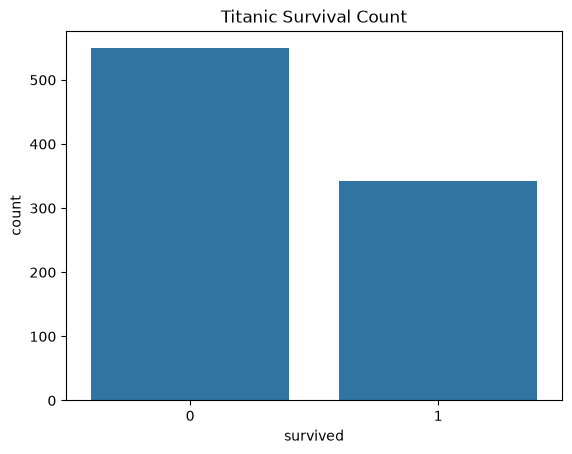

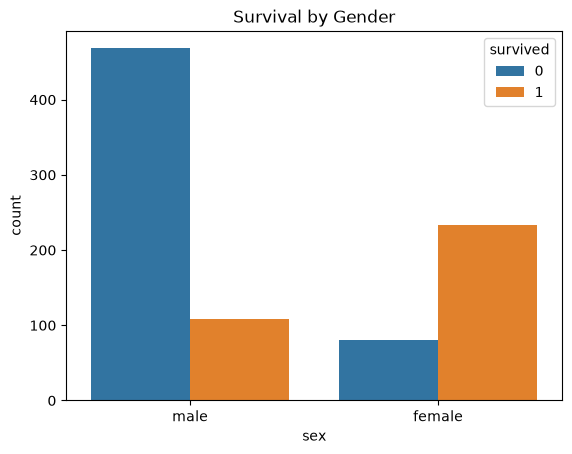

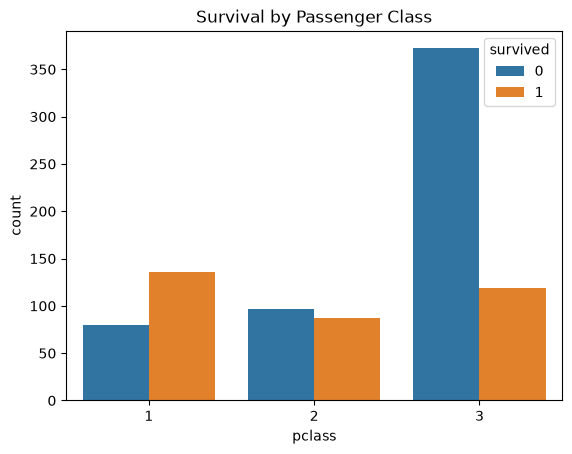

In [6]:
sns.countplot(x="survived", data=df)
plt.title("Titanic Survival Count")
plt.show()

sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.show()

sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

In [7]:
features = ["pclass","sex","age","sibsp","parch","fare","embarked"]
X = df[features].copy()
y = df["survived"]


X["age"] = X["age"].fillna(X["age"].median())

X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])
print(X.isnull().sum())

X = pd.get_dummies(X,columns=["sex", "embarked"],drop_first=True)
print(X.head())

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64
   pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42,stratify=y)
scaler = StandardScaler()

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training completed")
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])

Model training completed
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]
